# Returning booster, part 4: high-fidelity propulsion — engine cluster, variable inertia, and actuator dynamics

In Parts 1–3 we modelled the booster as a single point-mass with a **single, idealised engine**: instantaneous throttle, instantaneous gimbal, and a **constant** inertia tensor. That was the right abstraction to make the trajectory-optimisation and MPC machinery work end-to-end without drowning in plant details. Part 3 closed the *environment* fidelity gap (atmosphere, drag, grid fins, multi-phase guidance). This notebook closes the *propulsion* fidelity gap, which is the next-biggest model error in a returning-booster simulation.

We will add three pieces of physics, each motivated by a real-world phenomenon:

1. **Engine cluster** — three engines (one centre, two outer at $\pm r_{eng}$), each with independent throttle and gimbal. We construct a **control-allocation matrix** that maps the MPC's commanded $(\mathbf{F}_{\text{body}}, \boldsymbol{\tau}_{\text{body}}) \in \mathbb{R}^6$ to per-engine commands via the Moore–Penrose pseudo-inverse $\mathbf{u}_{\text{eng}} = A^{+} \mathbf{u}_{\text{cmd}}$. Outer engines provide differential thrust — a much more authoritative roll/pitch effector than a single-engine gimbal alone.

2. **Variable inertia** — as fuel depletes the total mass falls by ~30% and the centre-of-mass shifts upward (propellant is concentrated in the lower half of the body). The pitch/yaw inertia drops correspondingly. At full throttle a $\sim$17% mass change causes a $\sim$30% change in pitch angular acceleration, which the controller must compensate.

3. **Actuator dynamics** — gimbal servos and throttle valves are bandwidth-limited. We model each as a first-order LTI with ~10 Hz (gimbal) and ~5 Hz (throttle) corner frequencies. This limits how fast the controller can correct high-frequency disturbances.

**This is a fidelity tutorial, not a controller-tuning tutorial.** We deliberately keep Part 3's controllers, gains, dispatcher, and MPC config. The point is to show that the *closed-loop architecture* absorbs richer physics without re-tuning: better fidelity does **not** necessarily mean a better landing residual — in fact the new plant is generally **harder** to land cleanly, and we report the resulting residuals honestly.

**Out of scope, deferred to future parts**: slosh dynamics (fuel sloshing in the tank — ~2 days of additional modelling), plume effects (exhaust impingement, ground effect), shared-propellant-line throttle coupling, engine startup transients, ignition transients.


## Prerequisites

You should have read **Part 3** (`part_3_returning_booster_atmosphere_and_phases.ipynb`). This notebook re-uses Part 3's `BoosterTrajopt`, `BoosterFull`-style state vector, atmosphere model, aerodynamic forces, grid-fin model, boost-back / aero-glide controllers, the multi-phase dispatcher, and the IPOPT-options monkey-patch verbatim. We extend the truth plant only.


## Imports and constants from Part 3

In [1]:
# Standard scientific Python
import time as time_mod
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# JAX with float64 — trajectory optimization needs the precision
from jax import config
config.update("jax_enable_x64", True)
import jax
import jax.numpy as jnp

# Jaxonomy
import jaxonomy
from jaxonomy.framework import LeafSystem
from jaxonomy.library import Constant, Clock, LookupTable1d, SourceBlock
from jaxonomy import logging as jx_logging
jx_logging.set_log_level(jx_logging.ERROR)

# Reproducibility
RNG_SEED = 0
np.random.seed(RNG_SEED)


In [2]:
# ---- Constants verbatim from Parts 1-3 ----
M_DRY     = 25_000.0
M_FUEL_0  = 12_000.0
T_MAX     = 800_000.0    # TOTAL max thrust across the cluster (we split across 3 engines)
ETA_MIN   = 0.4
ETA_MAX   = 1.0
ISP       = 280.0
G0        = 9.80665
G         = 9.81
DELTA_MAX = np.deg2rad(10.0)
L_BOOSTER = 40.0
R_BOOSTER = 1.85

# Atmosphere + aero (Part 3)
RHO_0    = 1.225
H_SCALE  = 8500.0
GAMMA_AIR = 1.4
R_GAS     = 287.05
T_ATM     = 288.15
A_REF     = np.pi * R_BOOSTER**2

MACH_BREAKS = np.array([0.0, 0.3, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0, 5.0])
CD_VALUES   = np.array([0.82, 0.82, 0.85, 0.90, 1.10, 1.15, 1.10, 0.95, 0.80, 0.70])
CN_ALPHA = 2.5
L_COM_TO_CP = 2.0

S_FIN         = 4.0
CL_DELTA_FIN  = 4.0
DELTA_FIN_MAX = np.deg2rad(20.0)
L_FIN_FROM_COM = 18.0

def cylinder_inertia(m, L, r):
    Ixx = Iyy = m * (3 * r**2 + L**2) / 12.0
    Izz = 0.5 * m * r**2
    return Ixx, Iyy, Izz

IXX0, IYY0, IZZ0 = cylinder_inertia(M_DRY + M_FUEL_0, L_BOOSTER, R_BOOSTER)
print(f"Constants loaded: M_TOTAL_0={M_DRY+M_FUEL_0:.0f} kg, T_MAX={T_MAX/1000:.0f} kN, ISP={ISP:.0f} s")


Constants loaded: M_TOTAL_0=37000 kg, T_MAX=800 kN, ISP=280 s


## New for Part 4 — engine cluster geometry and control allocation

Falcon 9's first stage has nine Merlin engines arranged in an **OctaWeb** (one centre engine + eight in a ring). For the returning-booster landing burn, real flight cards light **1, 2, or 3 engines** depending on phase: typically 3 engines for the high-deceleration entry/landing burn (to maximize braking authority), tapering to 1 engine for the final touchdown (lower thrust-to-weight, finer control).

We model this with **three engines** in a triangular pattern:
* Engine 0: centre, at body-frame position $(0, 0, -L/2)$ (at the bottom of the booster, on the centreline).
* Engines 1, 2: outer ring at radius $r_{\text{eng}} = 1.3$ m from centerline, symmetric about the body $y$-axis.

Each engine independently produces thrust $\eta_i T_{\text{eng,max}}$ with gimbal angles $(\delta_{y,i}, \delta_{z,i})$. The total max thrust across the three engines is fixed at the Part-3 value (`T_MAX = 800 kN`) so we don't accidentally make landing easier — each engine maxes out at `T_MAX / 3`.

### The allocation problem

Given a *commanded* total body-frame force $\mathbf{F}_b^{\text{cmd}}$ and body-frame torque $\boldsymbol{\tau}_b^{\text{cmd}}$ (a 6-vector), we need to find per-engine commands. The forward map (per-engine commands $\to$ total $(\mathbf{F}_b, \boldsymbol{\tau}_b)$) is **nonlinear** because of $\sin\delta_y$, $\sin\delta_z$ inside each engine.

For control allocation we **linearize about $\delta=0$** ($\sin\delta \approx \delta$, $\cos\delta \approx 1$):

$$
\mathbf{F}_{b,i} \;\approx\; \eta_i T_{\text{eng,max}} \,(\delta_{y,i},\;-\delta_{z,i},\;1)^\top,
\qquad
\boldsymbol{\tau}_{b,i} \;\approx\; \mathbf{r}_i \times \mathbf{F}_{b,i}.
$$

Stack the 9 unknowns and we get a linear map $\mathbf{u}_{\text{cmd}}^{(6)} = A\,\mathbf{u}_{\text{eng}}^{(9)}$. The unconstrained least-squares solution is $\mathbf{u}_{\text{eng}}^\star = A^{+}\mathbf{u}_{\text{cmd}}$ where $A^{+}$ is the Moore–Penrose pseudo-inverse — and because the system is *over-actuated* in some torque axes, this picks the **minimum-norm** allocation, which spreads control effort across engines for fault tolerance.

Concretely we use the substitution $q_{y,i} := \eta_i \delta_{y,i}$ (small-angle linearization of the lateral-force-per-engine) so that the unknowns become linear in the wrench: 6 such $q$ variables + 3 engine throttles = 9 unknowns. After the pseudo-inverse we recover the per-engine gimbal as $\delta_{y,i} = q_{y,i}/\eta_i$.


In [3]:
# ---- Engine cluster geometry ----
N_ENGINES   = 3
T_ENG_MAX   = T_MAX / N_ENGINES     # per-engine max thrust [N]
R_ENG       = 1.30                  # outer-engine offset from centerline [m]
ENGINE_POS_BODY = np.array([
    [   0.0,            0.0,           -L_BOOSTER/2.0],   # centre
    [ R_ENG,            0.0,           -L_BOOSTER/2.0],   # outer +y
    [-R_ENG,            0.0,           -L_BOOSTER/2.0],   # outer -y
])
DELTA_MAX_ENG = DELTA_MAX            # keep at 10 deg per engine

print(f"Cluster geometry: {N_ENGINES} engines, outer ring at +/-{R_ENG:.2f} m")
print(f"Per-engine max thrust: {T_ENG_MAX/1000:.0f} kN  (total {N_ENGINES*T_ENG_MAX/1000:.0f} kN)")


Cluster geometry: 3 engines, outer ring at +/-1.30 m
Per-engine max thrust: 267 kN  (total 800 kN)


In [4]:
# ---- Linearized allocation matrix ----
# Unknown vector u_eng = [q_y0, q_z0, q_y1, q_z1, q_y2, q_z2, eta0, eta1, eta2]
# where q_yi := eta_i * delta_y_i, q_zi := eta_i * delta_z_i.
def _build_allocation_matrix(engine_positions=ENGINE_POS_BODY, T_eng_max=T_ENG_MAX):
    B = np.zeros((6, 9))
    for i, r_i in enumerate(engine_positions):
        rx, ry, rz = r_i
        # Lateral force contributions
        B[0, 2*i]   += T_eng_max               # F_x from q_yi (= sin d_y * eta)
        B[1, 2*i+1] += -T_eng_max              # F_y from q_zi (= -sin d_z * eta)
        B[2, 6 + i] += T_eng_max               # F_z from eta_i (=cos d cos d * eta)
        # Torque from engine i: r_i x F_b_i
        # tau_x = ry * Fz - rz * Fy
        B[3, 6 + i] += ry * T_eng_max
        B[3, 2*i+1] += rz * T_eng_max          # - rz * (-T_eng_max * q_z) = rz*T*q_z
        # tau_y = rz * Fx - rx * Fz
        B[4, 2*i]   += rz * T_eng_max
        B[4, 6 + i] += -rx * T_eng_max
        # tau_z = rx * Fy - ry * Fx
        B[5, 2*i+1] += -rx * T_eng_max
        B[5, 2*i]   += -ry * T_eng_max
    return B

ALLOC_B = _build_allocation_matrix()
ALLOC_B_PINV = np.linalg.pinv(ALLOC_B)
print(f"Allocation matrix B: shape {ALLOC_B.shape}, rank {np.linalg.matrix_rank(ALLOC_B)}")
print(f"Singular values: {np.linalg.svd(ALLOC_B, compute_uv=False)}")
sv = np.linalg.svd(ALLOC_B, compute_uv=False)
print(f"Condition number (sigma_max / sigma_min): {sv[0]/sv[-1]:.2e}")


Allocation matrix B: shape (6, 9), rank 5
Singular values: [9.26209612e+06 9.24914410e+06 4.90260702e+05 4.61880215e+05
 2.44482151e+04 7.49080699e-11]
Condition number (sigma_max / sigma_min): 1.24e+17


**Reading the singular values.** The smallest singular value corresponds to the *least-controllable* direction of the wrench space. The 3-engine cluster has redundancy in some torque axes (roll about body-z can be produced by differential throttle of the outer pair OR by gimbal of any engine) and has no redundancy in others (body-z force is just the sum of throttles). The pseudo-inverse picks the **minimum-norm** allocation, automatically distributing control effort across engines.


## New for Part 4 — variable inertia tensor

Real launch vehicles burn through a huge fraction of their total mass during a single burn. For our 25 t dry / 12 t fuel booster, draining the tank reduces total mass from 37 t to 25 t (a 33% drop). Two consequences:

1. **Mass decreases**, so linear acceleration $\mathbf{F}/m$ grows for fixed thrust.
2. **Inertia tensor changes**, because the fuel mass distribution shifts as the tank empties.

We model the fuel as a uniform-density slab occupying the **lower half** of the body (from $z = -L/2$ to $z = 0$ in body frame, where the body origin is the dry-mass centre). As fuel depletes, the *height* of the fuel column shrinks but its bottom stays anchored at $z = -L/2$. This means:
* The fuel sub-COM moves *downward* from $z = -L/4$ (full tank) toward $z = -L/2$ (empty).
* The *total* COM (mixing dry-mass COM at $z = 0$ with fuel COM) shifts *upward* as fuel depletes — net effect because the heavy fuel chunk leaves and the lighter dry mass dominates.
* Pitch/yaw inertias $I_{xx}, I_{yy}$ drop substantially (less mass, smaller moment arms).

These are simplified parameterisations; a real flight model would use CAD-derived inertia interpolation tables. The qualitative effect (and its impact on attitude control) is captured well.


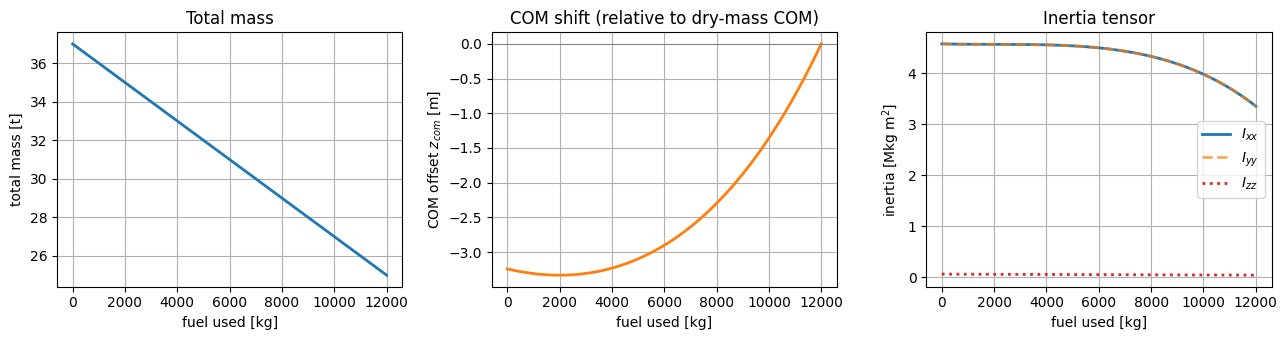


Mass change:  37.0 t -> 25.0 t  (-32%)
Pitch inertia: 4.58 -> 3.35 Mkg m^2  (-27%)
Max pitch accel @ max gimbal: 34.8 -> 47.5 deg/s^2  (+36%)
COM shift: -3.24 -> 0.00 m


In [5]:
# ---- Variable inertia parameterization ----
def fuel_geometry(m_fuel, L=L_BOOSTER, m_fuel_max=M_FUEL_0):
    """Return (h_fuel, z_com_fuel) for current fuel mass."""
    m_fuel_safe = jnp.maximum(m_fuel, 0.0)
    h_fuel = (m_fuel_safe / m_fuel_max) * (L / 2.0)
    z_com_fuel = -L/2.0 + 0.5 * h_fuel
    return h_fuel, z_com_fuel


def variable_inertia(m_fuel, m_dry=M_DRY, L=L_BOOSTER, r=R_BOOSTER, m_fuel_max=M_FUEL_0):
    """Return (m_total, z_com, Ixx, Iyy, Izz) about the combined COM.

    Dry mass: thin-walled cylinder centered at z=0; standard cylinder inertia.
    Fuel: solid slab of height h_fuel, radius r, sub-COM at z_com_fuel.
    Combined COM via mass-weighted average; combined I via parallel-axis."""
    m_fuel_safe = jnp.maximum(m_fuel, 0.0)
    m_total = m_dry + m_fuel_safe
    z_com_dry = 0.0
    h_fuel, z_com_fuel = fuel_geometry(m_fuel_safe, L=L, m_fuel_max=m_fuel_max)
    z_com = (m_dry * z_com_dry + m_fuel_safe * z_com_fuel) / jnp.maximum(m_total, 1e-6)
    Ixx_dry = m_dry * (3.0 * r**2 + L**2) / 12.0
    Iyy_dry = Ixx_dry
    Izz_dry = 0.5 * m_dry * r**2
    Ixx_fuel = m_fuel_safe * (3.0 * r**2 + h_fuel**2) / 12.0
    Iyy_fuel = Ixx_fuel
    Izz_fuel = 0.5 * m_fuel_safe * r**2
    d_dry  = z_com_dry  - z_com
    d_fuel = z_com_fuel - z_com
    Ixx = Ixx_dry + m_dry * d_dry**2 + Ixx_fuel + m_fuel_safe * d_fuel**2
    Iyy = Iyy_dry + m_dry * d_dry**2 + Iyy_fuel + m_fuel_safe * d_fuel**2
    Izz = Izz_dry + Izz_fuel
    return m_total, z_com, Ixx, Iyy, Izz


# Visualize variable inertia evolution
m_fuels = np.linspace(M_FUEL_0, 0.0, 200)
m_tots, z_coms, ixxs, iyys, izzs = [], [], [], [], []
for mf in m_fuels:
    m, zc, ix, iy, iz = variable_inertia(jnp.asarray(mf))
    m_tots.append(float(m)); z_coms.append(float(zc))
    ixxs.append(float(ix)); iyys.append(float(iy)); izzs.append(float(iz))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
ax = axes[0]
ax.plot(M_FUEL_0 - m_fuels, np.asarray(m_tots) / 1000.0, lw=2)
ax.set_xlabel("fuel used [kg]"); ax.set_ylabel("total mass [t]")
ax.set_title("Total mass"); ax.grid(True)
ax = axes[1]
ax.plot(M_FUEL_0 - m_fuels, np.asarray(z_coms), lw=2, color="tab:orange")
ax.set_xlabel("fuel used [kg]"); ax.set_ylabel("COM offset $z_{com}$ [m]")
ax.set_title("COM shift (relative to dry-mass COM)"); ax.grid(True)
ax.axhline(0, color="0.5", lw=0.7)
ax = axes[2]
ax.plot(M_FUEL_0 - m_fuels, np.asarray(ixxs)/1e6, lw=2, label=r"$I_{xx}$")
ax.plot(M_FUEL_0 - m_fuels, np.asarray(iyys)/1e6, lw=2, ls="--", label=r"$I_{yy}$", alpha=0.7)
ax.plot(M_FUEL_0 - m_fuels, np.asarray(izzs)/1e6, lw=2, ls=":", color="tab:red", label=r"$I_{zz}$")
ax.set_xlabel("fuel used [kg]"); ax.set_ylabel("inertia [Mkg m$^2$]")
ax.set_title("Inertia tensor"); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

m_full = m_tots[0]; m_empty = m_tots[-1]
Iy_full = iyys[0]; Iy_empty = iyys[-1]
tau_max = (L_BOOSTER/2.0) * T_MAX * np.sin(DELTA_MAX)
theta_dd_full  = tau_max / Iy_full
theta_dd_empty = tau_max / Iy_empty
print(f"\nMass change:  {m_full/1000:.1f} t -> {m_empty/1000:.1f} t  "
      f"({(m_empty/m_full - 1)*100:+.0f}%)")
print(f"Pitch inertia: {Iy_full/1e6:.2f} -> {Iy_empty/1e6:.2f} Mkg m^2  "
      f"({(Iy_empty/Iy_full - 1)*100:+.0f}%)")
print(f"Max pitch accel @ max gimbal: {np.rad2deg(theta_dd_full):.1f} -> "
      f"{np.rad2deg(theta_dd_empty):.1f} deg/s^2  "
      f"({(theta_dd_empty/theta_dd_full - 1)*100:+.0f}%)")
print(f"COM shift: {z_coms[0]:.2f} -> {z_coms[-1]:.2f} m")


**Figure 1.** Left: total mass falls linearly from 37 t to 25 t. Middle: the COM shifts *upward* as the heavy fuel slab drains. Right: pitch and yaw inertias fall by $\sim$30%; roll inertia barely changes (dominated by radius, not length). The headline: **at full gimbal, the empty booster pitches $\sim$30% faster than the full booster** — a control loop tuned for "average" conditions will be slow at the start of the burn and oscillatory at the end.


## New for Part 4 — actuator dynamics

The MPC produces a control command and the booster instantly applies it. In reality, the throttle valve and gimbal servo are mechanical systems with finite bandwidth. We model each as a **first-order LTI**:

$$
\tau_{\text{servo}} \dot{\delta}(t) + \delta(t) = \delta_{\text{cmd}}(t)
\;\Leftrightarrow\;
\delta(s) = \frac{1}{\tau_{\text{servo}} s + 1}\,\delta_{\text{cmd}}(s).
$$

Time constants:
* Gimbal servo: $\tau_g \approx 16$ ms (corner frequency $\sim 10$ Hz). Real F9 TVC bandwidth is published as $\sim$$10$–$20$ Hz.
* Throttle valve: $\tau_\eta \approx 32$ ms (corner $\sim 5$ Hz). Throttle response is dominated by combustion-chamber pressure and main-valve actuation.

Implementation: we bake the actuator dynamics into the booster plant as additional continuous states. The base-13 booster state is extended to 22:

$$
\mathbf{x} = \underbrace{[\mathbf{p}, \mathbf{v}, \boldsymbol{\eta}_a, \boldsymbol{\omega}, m_f]}_{13}\;
\oplus\;\underbrace{[\eta_{e,0}, \eta_{e,1}, \eta_{e,2}]}_{3 \text{ throttles}}\;
\oplus\;\underbrace{[\delta_{y,0}, \delta_{z,0}, \dots, \delta_{y,2}, \delta_{z,2}]}_{6 \text{ gimbals}}.
$$


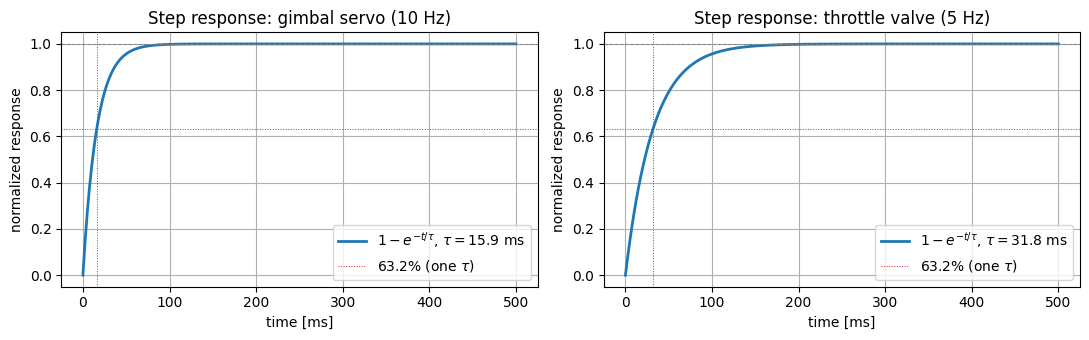

Gimbal servo time constant:    15.9 ms (corner 10 Hz)
Throttle valve time constant:  31.8 ms (corner  5 Hz)
MPC update interval:          400.0 ms (one MPC tick = 25 gimbal-tau)


In [6]:
TAU_GIMBAL_SERVO  = 1.0 / (2.0 * np.pi * 10.0)   # 10 Hz corner -> tau ~16 ms
TAU_THROTTLE      = 1.0 / (2.0 * np.pi *  5.0)   # 5  Hz corner -> tau ~32 ms

t_steps = np.linspace(0.0, 0.5, 200)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, tau, label, corner in [
    (axes[0], TAU_GIMBAL_SERVO, "gimbal servo (10 Hz)", 10.0),
    (axes[1], TAU_THROTTLE,     "throttle valve (5 Hz)", 5.0),
]:
    resp = 1.0 - np.exp(-t_steps / tau)
    ax.plot(t_steps * 1000, resp, lw=2, label=f"$1 - e^{{-t/\\tau}}$, $\\tau={tau*1000:.1f}$ ms")
    ax.axhline(1.0, color="0.5", lw=0.7, ls="--")
    ax.axhline(0.632, color="tab:red", lw=0.7, ls=":", label=r"63.2% (one $\tau$)")
    ax.axvline(tau*1000, color="tab:red", lw=0.7, ls=":")
    ax.set_xlabel("time [ms]"); ax.set_ylabel("normalized response")
    ax.set_title(f"Step response: {label}"); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()
print(f"Gimbal servo time constant:   {TAU_GIMBAL_SERVO*1000:5.1f} ms (corner 10 Hz)")
print(f"Throttle valve time constant: {TAU_THROTTLE*1000:5.1f} ms (corner  5 Hz)")
print(f"MPC update interval:          {0.4*1000:5.1f} ms (one MPC tick = "
      f"{0.4/TAU_GIMBAL_SERVO:.0f} gimbal-tau)")


**Figure 2.** Classical first-order step responses. The actuator reaches 63.2% of the commanded value after one time constant. With an MPC update interval of 400 ms, we have $\sim$25 gimbal time constants per MPC tick — so within a single MPC horizon the actuators look quasi-static **on average**, but during the first 50 ms after a command change there is a visible lag that limits closed-loop bandwidth.


## Re-use Part 3: atmosphere, aero, grid fins, trajopt plant


In [7]:
# ---- Atmosphere + aero (Part 3, verbatim) ----
def rho_air(z):
    return RHO_0 * jnp.exp(-jnp.maximum(z, 0.0) / H_SCALE)

def speed_of_sound(_z):
    return jnp.sqrt(GAMMA_AIR * R_GAS * T_ATM)


def aero_forces_and_moments(state, fin_pitch, fin_yaw):
    pos = state[0:3]; vel = state[3:6]
    phi, theta, psi = state[6:9]
    z = pos[2]
    rho = rho_air(z); a_s = speed_of_sound(z)
    cphi, sphi = jnp.cos(phi), jnp.sin(phi)
    cth,  sth  = jnp.cos(theta), jnp.sin(theta)
    cpsi, spsi = jnp.cos(psi), jnp.sin(psi)
    R_wb = jnp.array([
        [cpsi*cth, cpsi*sth*sphi - spsi*cphi, cpsi*sth*cphi + spsi*sphi],
        [spsi*cth, spsi*sth*sphi + cpsi*cphi, spsi*sth*cphi - cpsi*sphi],
        [-sth,     cth*sphi,                   cth*cphi                  ],
    ])
    v_W = vel
    V = jnp.linalg.norm(v_W) + 1e-6
    v_B = R_wb.T @ v_W
    mach = V / a_s
    q_dyn = 0.5 * rho * V**2
    Cd = jnp.interp(mach, jnp.asarray(MACH_BREAKS), jnp.asarray(CD_VALUES))
    F_drag_W = -Cd * A_REF * q_dyn * (v_W / V)
    alpha_y = -v_B[0] / V
    alpha_x = -v_B[1] / V
    F_normal_B = q_dyn * A_REF * CN_ALPHA * jnp.array([alpha_y, alpha_x, 0.0])
    F_normal_W = R_wb @ F_normal_B
    r_cp = jnp.array([0.0, 0.0, L_COM_TO_CP])
    tau_normal_B = jnp.cross(r_cp, F_normal_B)
    F_fin_B = 2.0 * q_dyn * S_FIN * CL_DELTA_FIN * jnp.array([fin_pitch, fin_yaw, 0.0])
    F_fin_W = R_wb @ F_fin_B
    r_fin = jnp.array([0.0, 0.0, L_FIN_FROM_COM])
    tau_fin_B = jnp.cross(r_fin, F_fin_B)
    F_aero_W = F_drag_W + F_normal_W + F_fin_W
    tau_aero_B = tau_normal_B + tau_fin_B
    F_aero_W = jnp.where(z > 0.0, F_aero_W, jnp.zeros(3))
    tau_aero_B = jnp.where(z > 0.0, tau_aero_B, jnp.zeros(3))
    return F_aero_W, tau_aero_B, q_dyn, mach


def euler_zyx_kinematics_inv(phi, theta):
    cphi, sphi = jnp.cos(phi), jnp.sin(phi)
    cth, sth = jnp.cos(theta), jnp.sin(theta)
    tth = sth / cth
    return jnp.array([
        [1.0, sphi*tth,   cphi*tth],
        [0.0, cphi,      -sphi    ],
        [0.0, sphi/cth,   cphi/cth],
    ])


def booster_trajopt_rhs(state, control,
                        m_dry=M_DRY, T_max=T_MAX, isp=ISP, g0=G0, g=G,
                        L=L_BOOSTER, Ixx=IXX0, Iyy=IYY0, Izz=IZZ0):
    pos   = state[0:3]; vel = state[3:6]
    eta_a = state[6:9]; omega = state[9:12]; m_f = state[12]
    eta_throttle, delta_y, delta_z = control
    phi, theta, psi = eta_a
    m_total = m_dry + jnp.maximum(m_f, 0.0)
    cphi, sphi = jnp.cos(phi), jnp.sin(phi)
    cth,  sth  = jnp.cos(theta), jnp.sin(theta)
    cpsi, spsi = jnp.cos(psi), jnp.sin(psi)
    R_wb = jnp.array([
        [cpsi*cth, cpsi*sth*sphi - spsi*cphi, cpsi*sth*cphi + spsi*sphi],
        [spsi*cth, spsi*sth*sphi + cpsi*cphi, spsi*sth*cphi - cpsi*sphi],
        [-sth,     cth*sphi,                   cth*cphi                  ],
    ])
    F_B = eta_throttle * T_max * jnp.array([
        jnp.sin(delta_y), -jnp.sin(delta_z), jnp.cos(delta_y) * jnp.cos(delta_z),
    ])
    F_thrust_W = R_wb @ F_B
    G_W = jnp.array([0.0, 0.0, -m_total * g])
    acc = (F_thrust_W + G_W) / m_total
    tau_B = jnp.array([
        -(L / 2.0) * eta_throttle * T_max * jnp.sin(delta_z),
        -(L / 2.0) * eta_throttle * T_max * jnp.sin(delta_y),
         0.0,
    ])
    I_diag = jnp.array([Ixx, Iyy, Izz])
    omega_dot = (tau_B - jnp.cross(omega, I_diag * omega)) / I_diag
    eta_dot = euler_zyx_kinematics_inv(phi, theta) @ omega
    m_f_dot = jnp.where(m_f > 0.0, -eta_throttle * T_max / (isp * g0), 0.0)
    return jnp.concatenate([vel, acc, eta_dot, omega_dot, jnp.array([m_f_dot])])


class BoosterTrajopt(LeafSystem):
    def __init__(self, x0=None, name="booster_trajopt"):
        super().__init__(name=name)
        if x0 is None:
            x0 = jnp.zeros(13)
        self.declare_input_port(name="u")
        self.declare_continuous_state(default_value=jnp.array(x0), ode=self.ode)
        self.declare_continuous_state_output(name="x")
    def ode(self, time, state, *inputs, **params):
        return booster_trajopt_rhs(state.continuous_state, inputs[0])


def booster_full_rhs(state, control,
                    m_dry=M_DRY, T_max=T_MAX, isp=ISP, g0=G0, g=G,
                    L=L_BOOSTER, Ixx=IXX0, Iyy=IYY0, Izz=IZZ0):
    pos   = state[0:3]; vel = state[3:6]
    eta_a = state[6:9]; omega = state[9:12]; m_f = state[12]
    eta_throttle, delta_y, delta_z, fin_pitch, fin_yaw = control
    phi, theta, psi = eta_a
    m_total = m_dry + jnp.maximum(m_f, 0.0)
    cphi, sphi = jnp.cos(phi), jnp.sin(phi)
    cth,  sth  = jnp.cos(theta), jnp.sin(theta)
    cpsi, spsi = jnp.cos(psi), jnp.sin(psi)
    R_wb = jnp.array([
        [cpsi*cth, cpsi*sth*sphi - spsi*cphi, cpsi*sth*cphi + spsi*sphi],
        [spsi*cth, spsi*sth*sphi + cpsi*cphi, spsi*sth*cphi - cpsi*sphi],
        [-sth,     cth*sphi,                   cth*cphi                  ],
    ])
    F_B = eta_throttle * T_max * jnp.array([
        jnp.sin(delta_y), -jnp.sin(delta_z), jnp.cos(delta_y) * jnp.cos(delta_z),
    ])
    F_thrust_W = R_wb @ F_B
    G_W = jnp.array([0.0, 0.0, -m_total * g])
    F_aero_W, tau_aero_B, _q, _M = aero_forces_and_moments(state, fin_pitch, fin_yaw)
    acc = (F_thrust_W + G_W + F_aero_W) / m_total
    tau_thrust_B = jnp.array([
        -(L / 2.0) * eta_throttle * T_max * jnp.sin(delta_z),
        -(L / 2.0) * eta_throttle * T_max * jnp.sin(delta_y),
         0.0,
    ])
    tau_total_B = tau_thrust_B + tau_aero_B
    I_diag = jnp.array([Ixx, Iyy, Izz])
    omega_dot = (tau_total_B - jnp.cross(omega, I_diag * omega)) / I_diag
    eta_dot = euler_zyx_kinematics_inv(phi, theta) @ omega
    m_f_dot = jnp.where(m_f > 0.0, -eta_throttle * T_max / (isp * g0), 0.0)
    return jnp.concatenate([vel, acc, eta_dot, omega_dot, jnp.array([m_f_dot])])


def booster_full_rhs_3vec(state, control3):
    fins = jnp.zeros(2)
    return booster_full_rhs(state, jnp.concatenate([control3, fins]))


class BoosterFull(LeafSystem):
    def __init__(self, x0=None, name="booster_full"):
        super().__init__(name=name)
        if x0 is None:
            x0 = jnp.zeros(13)
        self.declare_input_port(name="u")
        self.declare_continuous_state(default_value=jnp.array(x0), ode=self.ode)
        self.declare_continuous_state_output(name="x")
    def ode(self, time, state, *inputs, **params):
        return booster_full_rhs(state.continuous_state, inputs[0])


class BoosterFullForMPC(LeafSystem):
    def __init__(self, x0=None, name="booster_full_for_mpc"):
        super().__init__(name=name)
        if x0 is None:
            x0 = jnp.zeros(13)
        self.declare_input_port(name="u")
        self.declare_continuous_state(default_value=jnp.array(x0), ode=self.ode)
        self.declare_continuous_state_output(name="x")
    def ode(self, time, state, *inputs, **params):
        return booster_full_rhs_3vec(state.continuous_state, inputs[0])

print("Part-3 plant + trajopt definitions re-loaded.")


Part-3 plant + trajopt definitions re-loaded.


## The new high-fidelity plant: `BoosterHiFi`

The new plant has **22 continuous states**:

| Indices | Meaning | Source |
|---------|---------|--------|
| 0–2     | World-frame position $(x, y, z)$ | base |
| 3–5     | World-frame velocity | base |
| 6–8     | Z-Y-X Euler angles $(\phi, \theta, \psi)$ | base |
| 9–11    | Body-frame angular velocity $\boldsymbol{\omega}$ | base |
| 12      | Fuel mass $m_f$ | base |
| 13–15   | Throttle of each of the 3 engines | Part 4 |
| 16–17   | Gimbal $(\delta_y, \delta_z)$ of engine 0 | Part 4 |
| 18–19   | Gimbal of engine 1 | Part 4 |
| 20–21   | Gimbal of engine 2 | Part 4 |

The dispatcher and MPC operate on the **13-state base** (they only see the first 13 components). The new states are internal plant state. The plant **input** is still the dispatcher's 5-vector $(\eta, \delta_y, \delta_z, \text{fin}_p, \text{fin}_y)$.

Inside the plant ODE we (1) **allocate** the aggregate $(\eta, \delta_y, \delta_z)$ across the 3 engines via $A^+$; (2) **filter** each per-engine command through its first-order actuator dynamics (states 13–21); (3) **sum** the 3 engines' instantaneous thrust + torque (using the actual, lagged per-engine values); (4) use **variable inertia** $I(m_f)$ and **variable COM** $z_{\text{com}}(m_f)$ in the moment computations.


In [8]:
ENGINE_POS_BODY_J = jnp.asarray(ENGINE_POS_BODY)
ALLOC_B_PINV_J    = jnp.asarray(ALLOC_B_PINV)

def allocate_engines(eta_cmd, delta_y_cmd, delta_z_cmd):
    """Map the dispatcher's aggregate (eta, delta_y, delta_z) -> per-engine cmds."""
    Fx_cmd = eta_cmd * T_MAX * jnp.sin(delta_y_cmd)
    Fy_cmd = -eta_cmd * T_MAX * jnp.sin(delta_z_cmd)
    Fz_cmd = eta_cmd * T_MAX * jnp.cos(delta_y_cmd) * jnp.cos(delta_z_cmd)
    tau_x_cmd = -(L_BOOSTER/2.0) * eta_cmd * T_MAX * jnp.sin(delta_z_cmd)
    tau_y_cmd = -(L_BOOSTER/2.0) * eta_cmd * T_MAX * jnp.sin(delta_y_cmd)
    tau_z_cmd = 0.0
    w_cmd = jnp.array([Fx_cmd, Fy_cmd, Fz_cmd, tau_x_cmd, tau_y_cmd, tau_z_cmd])
    u_eng = ALLOC_B_PINV_J @ w_cmd
    q_y = u_eng[jnp.array([0, 2, 4])]
    q_z = u_eng[jnp.array([1, 3, 5])]
    etas = u_eng[6:9]
    etas_safe = jnp.clip(etas, ETA_MIN, ETA_MAX)
    delta_y = jnp.clip(q_y / etas_safe, -DELTA_MAX_ENG, DELTA_MAX_ENG)
    delta_z = jnp.clip(q_z / etas_safe, -DELTA_MAX_ENG, DELTA_MAX_ENG)
    return etas_safe, delta_y, delta_z


def hifi_thrust_and_torque(state_22, m_total, z_com):
    """Compute body-frame thrust + torque from LAGGED per-engine actuator states."""
    etas    = state_22[13:16]
    deltas_y = state_22[jnp.array([16, 18, 20])]
    deltas_z = state_22[jnp.array([17, 19, 21])]
    def per_engine(eta_i, dy_i, dz_i, pos_i):
        F_B_i = eta_i * T_ENG_MAX * jnp.array([
            jnp.sin(dy_i), -jnp.sin(dz_i),
            jnp.cos(dy_i) * jnp.cos(dz_i),
        ])
        r_i = pos_i - jnp.array([0.0, 0.0, z_com])
        tau_B_i = jnp.cross(r_i, F_B_i)
        mdot_i = eta_i * T_ENG_MAX / (ISP * G0)
        return F_B_i, tau_B_i, mdot_i
    F_per, tau_per, mdot_per = jax.vmap(per_engine, in_axes=(0, 0, 0, 0))(
        etas, deltas_y, deltas_z, ENGINE_POS_BODY_J
    )
    return jnp.sum(F_per, axis=0), jnp.sum(tau_per, axis=0), jnp.sum(mdot_per)


def booster_hifi_rhs(state22, control5):
    """Full Part-4 plant ODE."""
    pos = state22[0:3]; vel = state22[3:6]
    eta_a = state22[6:9]; omega = state22[9:12]; m_f = state22[12]
    eta_cmd, dy_cmd, dz_cmd, fin_pitch, fin_yaw = control5

    m_total, z_com, Ixx, Iyy, Izz = variable_inertia(m_f)

    etas_cmd, dys_cmd, dzs_cmd = allocate_engines(eta_cmd, dy_cmd, dz_cmd)
    etas_state    = state22[13:16]
    dys_state     = state22[jnp.array([16, 18, 20])]
    dzs_state     = state22[jnp.array([17, 19, 21])]
    detas    = (etas_cmd - etas_state) / TAU_THROTTLE
    ddys     = (dys_cmd  - dys_state)  / TAU_GIMBAL_SERVO
    ddzs     = (dzs_cmd  - dzs_state)  / TAU_GIMBAL_SERVO

    phi, theta, psi = eta_a
    cphi, sphi = jnp.cos(phi), jnp.sin(phi)
    cth,  sth  = jnp.cos(theta), jnp.sin(theta)
    cpsi, spsi = jnp.cos(psi), jnp.sin(psi)
    R_wb = jnp.array([
        [cpsi*cth, cpsi*sth*sphi - spsi*cphi, cpsi*sth*cphi + spsi*sphi],
        [spsi*cth, spsi*sth*sphi + cpsi*cphi, spsi*sth*cphi - cpsi*sphi],
        [-sth,     cth*sphi,                   cth*cphi                  ],
    ])

    F_thrust_B, tau_thrust_B, mdot_total = hifi_thrust_and_torque(state22, m_total, z_com)
    F_thrust_W = R_wb @ F_thrust_B
    G_W = jnp.array([0.0, 0.0, -m_total * G])

    state_base = state22[0:13]
    F_aero_W, tau_aero_B, _q, _M = aero_forces_and_moments(state_base, fin_pitch, fin_yaw)

    acc = (F_thrust_W + G_W + F_aero_W) / m_total
    tau_total_B = tau_thrust_B + tau_aero_B
    I_diag = jnp.array([Ixx, Iyy, Izz])
    omega_dot = (tau_total_B - jnp.cross(omega, I_diag * omega)) / I_diag
    eta_a_dot = euler_zyx_kinematics_inv(phi, theta) @ omega
    m_f_dot = jnp.where(m_f > 0.0, -mdot_total, 0.0)
    dx_base = jnp.concatenate([vel, acc, eta_a_dot, omega_dot, jnp.array([m_f_dot])])
    dx_throttles = detas
    dx_gimbals = jnp.stack([ddys[0], ddzs[0], ddys[1], ddzs[1], ddys[2], ddzs[2]])
    return jnp.concatenate([dx_base, dx_throttles, dx_gimbals])


def make_hifi_initial_state(x_base_13, engine_kill=None):
    x22 = np.zeros(22)
    x22[0:13] = x_base_13
    x22[13:16] = ETA_MIN
    x22[16:22] = 0.0
    return x22


class BoosterHiFi(LeafSystem):
    """22-state hi-fi booster: cluster + variable inertia + actuator dynamics."""
    def __init__(self, x0=None, name="booster_hifi"):
        super().__init__(name=name)
        if x0 is None:
            x0 = jnp.zeros(22)
        self.declare_input_port(name="u")
        self.declare_continuous_state(default_value=jnp.asarray(x0), ode=self.ode)
        self.declare_continuous_state_output(name="x")
    def ode(self, time, state, *inputs, **params):
        return booster_hifi_rhs(state.continuous_state, inputs[0])

print("BoosterHiFi defined: 22 continuous states (13 base + 3 throttle + 6 gimbal)")


BoosterHiFi defined: 22 continuous states (13 base + 3 throttle + 6 gimbal)


### Smoke test: nominal hover

Before composing with the MPC, verify the new plant by simulating a static hover command (throttle $= mg/T_{\max}$, zero gimbal, zero fins) for a short window. The booster should stay nearly stationary.


In [9]:
x0_hover_base = np.array([
    0.0, 0.0, 1000.0,
    0.0, 0.0,    0.0,
    0.0, 0.0,    0.0,
    0.0, 0.0,    0.0,
    M_FUEL_0,
])
x0_hover = make_hifi_initial_state(x0_hover_base)
eta_hover = (M_DRY + M_FUEL_0) * G / T_MAX
builder = jaxonomy.DiagramBuilder()
plant_hover = builder.add(BoosterHiFi(x0=jnp.asarray(x0_hover), name="hover_test"))
u_hover = builder.add(Constant(value=jnp.array([eta_hover, 0.0, 0.0, 0.0, 0.0]), name="u_hover"))
builder.connect(u_hover.output_ports[0], plant_hover.input_ports[0])
diag_hover = builder.build()
ctx_hover = diag_hover.create_context()
res_hover = jaxonomy.simulate(
    diag_hover, ctx_hover, (0.0, 5.0),
    options=jaxonomy.SimulatorOptions(max_major_steps=400),
    recorded_signals={"x": plant_hover.output_ports[0]},
)
x_hov = np.asarray(res_hover.outputs["x"])
print(f"Hover-hold smoke test ({len(res_hover.time)} samples over 5 s):")
print(f"  altitude drift over 5 s: {x_hov[-1, 2] - x_hov[0, 2]:+.2f} m  (expected ~0)")
print(f"  attitude drift:          {np.rad2deg(np.linalg.norm(x_hov[-1, 6:9])):.2f} deg")
print(f"  engine 0 throttle settled at: {x_hov[-1, 13]:.3f}  (commanded {eta_hover:.3f})")
print(f"  engine 1 throttle settled at: {x_hov[-1, 14]:.3f}")
print(f"  engine 2 throttle settled at: {x_hov[-1, 15]:.3f}")


Hover-hold smoke test (98 samples over 5 s):
  altitude drift over 5 s: +0.55 m  (expected ~0)
  attitude drift:          0.00 deg
  engine 0 throttle settled at: 0.454  (commanded 0.454)
  engine 1 throttle settled at: 0.454
  engine 2 throttle settled at: 0.454


## Dispatcher and controllers — re-used from Part 3

We re-use Part 3's `boost_back_controller`, `aero_glide_controller`, the MPC config, the IPOPT monkey-patch, and the dispatcher **without modification**. The dispatcher reads only the first 13 components of the plant state, so the extension to 22 states is transparent. A `StateSlice13` block exposes just the base state to the dispatcher and MPC.


In [10]:
X0_PHASE1_BASE = np.array([
    4000.0, 0.0, 9000.0,
    -100.0, 0.0,  -20.0,
    0.0, 0.0, 0.0,
    0.0, 0.0, 0.0,
    M_FUEL_0,
])

BBB_TILT_TARGET = jnp.deg2rad(-30.0)
ETA_BBB         = 0.5
K_X_GLIDE       = 2.0e-4
K_V_GLIDE       = 6.0e-3

def _wrap_to_pi(angle):
    return (angle + jnp.pi) % (2.0 * jnp.pi) - jnp.pi


def boost_back_controller(state):
    eta_a = state[6:9]; omega = state[9:12]
    K_p_att, K_d_att = 0.5, 0.5
    theta_err = _wrap_to_pi(eta_a[1] - BBB_TILT_TARGET)
    phi_err   = _wrap_to_pi(eta_a[0])
    delta_y_cmd = jnp.clip( K_p_att * theta_err + K_d_att * omega[1],
                            -DELTA_MAX, DELTA_MAX)
    delta_z_cmd = jnp.clip( K_p_att * phi_err   + K_d_att * omega[0],
                            -DELTA_MAX, DELTA_MAX)
    return jnp.array([ETA_BBB, delta_y_cmd, delta_z_cmd, 0.0, 0.0])


def aero_glide_controller(state):
    pos   = state[0:3]; vel = state[3:6]
    omega = state[9:12]; eta_a = state[6:9]
    K_x = K_X_GLIDE; K_v = K_V_GLIDE
    theta_target = jnp.clip( K_x * pos[0] + K_v * vel[0],
                             -jnp.deg2rad(15.0), jnp.deg2rad(15.0) )
    phi_target   = jnp.clip(-K_x * pos[1] - K_v * vel[1],
                             -jnp.deg2rad(15.0), jnp.deg2rad(15.0) )
    K_p, K_d = 0.50, 0.20
    pitch_err = _wrap_to_pi(eta_a[1] - theta_target)
    phi_err   = _wrap_to_pi(eta_a[0] - phi_target)
    fin_pitch_cmd = jnp.clip(-K_p * pitch_err - K_d * omega[1],
                              -DELTA_FIN_MAX, DELTA_FIN_MAX)
    fin_yaw_cmd   = jnp.clip( K_p * phi_err   + K_d * omega[0],
                              -DELTA_FIN_MAX, DELTA_FIN_MAX)
    return jnp.array([0.0, 0.0, 0.0, fin_pitch_cmd, fin_yaw_cmd])


def predicted_ballistic_x(state):
    z = state[2]; vz = state[5]; x = state[0]; vx = state[3]
    discrim = vz*vz + 2.0 * G * jnp.maximum(z, 0.0)
    t_fall = (-vz + jnp.sqrt(jnp.maximum(discrim, 0.0))) / G
    return x + vx * t_fall


Z_LANDING_TRIGGER = 1500.0
T_BBB_MAX         = 15.0
X_LAND_TARGET     = 600.0

class MultiPhaseDispatcher(LeafSystem):
    def __init__(self, name="dispatcher"):
        super().__init__(name=name)
        self.declare_input_port(name="x")
        self.declare_input_port(name="u_mpc")
        def _phase(time, state, *inputs, **parameters):
            x, _u_mpc = inputs
            z = x[2]
            in_landing = z < Z_LANDING_TRIGGER
            bbb_active = (~in_landing) & (time < T_BBB_MAX)
            phase = jnp.where(in_landing, 2,
                              jnp.where(bbb_active, 0, 1))
            return phase.astype(jnp.float64)
        def _output(time, state, *inputs, **parameters):
            x, u_mpc = inputs
            phase = _phase(time, state, *inputs, **parameters)
            phase_int = jnp.clip(jnp.round(phase).astype(jnp.int32), 0, 2)
            u_land5 = jnp.concatenate([u_mpc, jnp.zeros(2)])
            return jax.lax.switch(
                phase_int,
                [
                    lambda: boost_back_controller(x),
                    lambda: aero_glide_controller(x),
                    lambda: u_land5,
                ],
            )
        self.declare_output_port(_output, name="u",
                                  default_value=jnp.zeros(5),
                                  requires_inputs=True)
        self.declare_output_port(_phase, name="phase",
                                  default_value=jnp.array(0.0),
                                  requires_inputs=True)


class StateSlice13(LeafSystem):
    """Forward only the first 13 components of the input vector."""
    def __init__(self, name="slice13"):
        super().__init__(name=name)
        self.declare_input_port(name="x_full")
        self.declare_output_port(
            lambda time, state, *inputs, **params: inputs[0][0:13],
            name="x_base", default_value=jnp.zeros(13), requires_inputs=True,
        )

print(f"Dispatcher and slice block ready.")


Dispatcher and slice block ready.


## Reference landing-burn trajectory (open-loop, Part-3 plant)

In [11]:
x0_landing_nom = np.array([
    420.0, 0.0, 630.0,
    -60.0, 0.0, -90.0,
    0.0, np.deg2rad(-10.0), 0.0,
    0.0, 0.0, 0.0,
    M_FUEL_0,
])
xf_target_arr = np.zeros(13)
T_BURN = 14.0
N_REF  = 30
nx, nu = 13, 3
Q_ref  = np.diag([1e-3]*3 + [1e-2]*3 + [1e-1]*3 + [1e-1]*3 + [0.0])
QN_ref = np.diag([1e5]*3  + [1e5]*3  + [1e4]*3  + [1e3]*3  + [0.0])
R_ref  = np.diag([1.0, 1e1, 1e1])
LB_X = np.array([-3000., -1000., 0.,
                 -300., -200., -200.,
                 np.deg2rad(-45.), np.deg2rad(-60.), np.deg2rad(-45.),
                 -2., -2., -2., 0.])
UB_X = np.array([ 3000.,  1000., 1500.,
                  300.,  200.,  200.,
                  np.deg2rad(45.), np.deg2rad(60.), np.deg2rad(45.),
                  2., 2., 2., M_FUEL_0])
LB_U = np.array([ETA_MIN, -DELTA_MAX, -DELTA_MAX])
UB_U = np.array([ETA_MAX,  DELTA_MAX,  DELTA_MAX])

def gravity_turn_warm_start(x0, xf, N, t_burn, m_total_avg):
    ts = np.linspace(0.0, 1.0, N + 1)[:, None]
    pos0, posf = np.asarray(x0[0:3]), np.asarray(xf[0:3])
    vel0, velf = np.asarray(x0[3:6]), np.asarray(xf[3:6])
    eta0, etaf = np.asarray(x0[6:9]), np.asarray(xf[6:9])
    om0, omf   = np.asarray(x0[9:12]), np.asarray(xf[9:12])
    mf0        = float(x0[12])
    pos = pos0 + ts * (posf - pos0)
    vel = vel0 + ts * (velf - vel0)
    eta_g = eta0 + ts * (etaf - eta0)
    om = om0 + ts * (omf - om0)
    a_z_req = -float(vel0[2]) / t_burn
    eta_const = float(np.clip(m_total_avg * (G + a_z_req) / T_MAX, ETA_MIN, ETA_MAX))
    mf_burn = eta_const * T_MAX / (ISP * G0)
    mf = np.clip(mf0 - mf_burn * ts.flatten() * t_burn, 0.0, mf0)
    x_g = np.hstack([pos, vel, eta_g, om, mf[:, None]])
    u_g = np.tile(np.array([eta_const, 0.0, 0.0]), (N + 1, 1))
    return x_g, u_g

x_guess0, u_guess0 = gravity_turn_warm_start(
    x0_landing_nom, xf_target_arr, N_REF, T_BURN,
    m_total_avg=M_DRY + 0.5*M_FUEL_0,
)
print("Solving Part-3 reference landing trajectory ...")
t0 = time_mod.time()
plant_ref = BoosterTrajopt(x0=jnp.asarray(x0_landing_nom), name="booster_ref")
x_ref, u_ref = jaxonomy.trajopt(
    plant_ref, t0=0.0, tf=T_BURN,
    x0=np.asarray(x0_landing_nom), xf=xf_target_arr,
    Q=Q_ref, R=R_ref, QN=QN_ref, N=N_REF,
    constrain_xf=False,
    lb_x=LB_X, ub_x=UB_X, lb_u=LB_U, ub_u=UB_U,
    x_guess=x_guess0, u_guess=u_guess0,
)
print(f"  reference solved in {time_mod.time()-t0:.1f} s, "
      f"terminal residual {np.linalg.norm(x_ref[-1, 0:3]):.2f} m")
t_ref_grid = np.linspace(0.0, T_BURN, N_REF + 1)


Solving Part-3 reference landing trajectory ...



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



  reference solved in 51.7 s, terminal residual 20.78 m


In [12]:
from jaxonomy.library import DirectShootingNMPC

N_MPC = 20
DT_MPC = 0.4
NH_MPC = 2
Q_mpc  = np.diag([1e-3]*3 + [1e-2]*3 + [1e-1]*3 + [1e-1]*3 + [0.0])
QN_mpc = np.diag([1e2]*3  + [5e4]*3  + [1e2]*3  + [1e1]*3  + [0.0])
R_mpc  = np.diag([1.0, 5.0, 5.0])
def u_warm(N, u_ref_arr):
    return jnp.tile(jnp.asarray(u_ref_arr[0]), (N, 1))

import cyipopt as _cyipopt
from jaxonomy.library.nmpc.base.nmpc_ipopt_base import NonlinearMPCIpopt as _NMPCBase

if not getattr(_NMPCBase, "_p4_patched", False):
    _orig_solve_method = _NMPCBase.solve
    def _patched_nmpc_solve(self, time, state, *inputs):
        t_curr = time
        x_curr, x_ref, u_ref = inputs
        self.nlp_structure_ipopt.update_nlp_structure(t_curr, x_curr, x_ref, u_ref)
        u_hot = jnp.tile(jnp.array([ETA_MAX, 0.0, 0.0]), self.N)
        optvars_guess = u_hot
        lb_optvars, ub_optvars = self.bounds_optvars
        lb_constraints, ub_constraints = self.bounds_constraints
        nlp = _cyipopt.Problem(
            n=self.num_optvars, m=self.num_constraints,
            problem_obj=self.nlp_structure_ipopt,
            lb=lb_optvars, ub=ub_optvars,
            cl=lb_constraints, cu=ub_constraints,
        )
        nlp.add_option("mu_strategy", "adaptive")
        nlp.add_option("tol", 1e-4)
        nlp.add_option("acceptable_tol", 1e-3)
        nlp.add_option("max_iter", 300)
        nlp.add_option("print_level", 0)
        try:
            sol, info = nlp.solve(optvars_guess)
        except Exception:
            sol = optvars_guess
        return jnp.array(sol)
    _NMPCBase.solve = _patched_nmpc_solve
    _NMPCBase._p4_patched = True

print(f"MPC reused from Part 3: N={N_MPC}, dt={DT_MPC}s, horizon={N_MPC*DT_MPC:.1f}s")


class ReferenceTrajectory(SourceBlock):
    def __init__(self, t_vec, x_arr, dt, N, *args, **kwargs):
        self.t_vec = t_vec; self.x_arr = x_arr; self.dt = dt; self.N = N
        self.interp_fun = jax.vmap(jnp.interp, (None, None, 1))
        super().__init__(self.reference_trajectory_for_N_steps, *args, **kwargs)
    def _scan_t(self, _carry, t):
        return _carry, self.interp_fun(t, self.t_vec, self.x_arr)
    def reference_trajectory_for_N_steps(self, t):
        t_steps = t + self.dt * jnp.arange(self.N + 1)
        _, x_i = jax.lax.scan(self._scan_t, None, t_steps)
        return x_i

T_REF_FINE = np.linspace(0.0, T_BURN, 1001)
X_REF_FINE = np.zeros((len(T_REF_FINE), nx))
U_REF_FINE = np.zeros((len(T_REF_FINE), nu))


MPC reused from Part 3: N=20, dt=0.4s, horizon=8.0s


## Compose the high-fidelity diagram and simulate

The only structural change relative to Part 3 is the **slice** block between the 22-state plant output and the dispatcher/MPC. Everything else is identical.


In [13]:
def make_hifi_diagram(x0_22):
    builder = jaxonomy.DiagramBuilder()
    plant = builder.add(BoosterHiFi(x0=jnp.asarray(x0_22), name="booster_hifi"))
    slc = builder.add(StateSlice13(name="state_slice"))
    mpc_model = BoosterFullForMPC(x0=jnp.asarray(x0_22[0:13]), name="mpc_internal_model")
    xref_block = builder.add(ReferenceTrajectory(
        T_REF_FINE, jnp.asarray(X_REF_FINE), DT_MPC, N_MPC, name="x_ref",
    ))
    uref_block = builder.add(ReferenceTrajectory(
        T_REF_FINE, jnp.asarray(U_REF_FINE), DT_MPC, N_MPC - 1, name="u_ref",
    ))
    mpc = builder.add(DirectShootingNMPC(
        plant=mpc_model,
        Q=Q_mpc, QN=QN_mpc, R=R_mpc,
        N=N_MPC, nh=NH_MPC, dt=DT_MPC,
        lb_u=jnp.asarray(LB_U), ub_u=jnp.asarray(UB_U),
        u_optvars_0=u_warm(N_MPC, U_REF_FINE),
        name="mpc",
    ))
    dispatcher = builder.add(MultiPhaseDispatcher(name="dispatcher"))
    builder.connect(plant.output_ports[0], slc.input_ports[0])
    builder.connect(slc.output_ports[0], mpc.input_ports[0])
    builder.connect(xref_block.output_ports[0], mpc.input_ports[1])
    builder.connect(uref_block.output_ports[0], mpc.input_ports[2])
    builder.connect(slc.output_ports[0], dispatcher.input_ports[0])
    builder.connect(mpc.output_ports[0], dispatcher.input_ports[1])
    builder.connect(dispatcher.output_ports[0], plant.input_ports[0])
    return builder.build(), plant, mpc, dispatcher


x0_phase1_hifi = make_hifi_initial_state(X0_PHASE1_BASE)
hifi_diag, hifi_plant, hifi_mpc, hifi_dispatch = make_hifi_diagram(x0_phase1_hifi)
print("High-fidelity diagram:")
hifi_diag.pprint()


High-fidelity diagram:
│── root <Diagram>
    │── booster_hifi <BoosterHiFi> [x → state_slice.x_full]
    │── state_slice <StateSlice13> [x_base → mpc.in_0, x_base → dispatcher.x]
    │── x_ref <ReferenceTrajectory> [out_0 → mpc.in_1]
    │── u_ref <ReferenceTrajectory> [out_0 → mpc.in_2]
    │── mpc <DirectShootingNMPC> [out_0 → dispatcher.u_mpc]
    │── dispatcher <MultiPhaseDispatcher> [u → booster_hifi.u]


In [14]:
T_TOTAL = 90.0
print("Simulating high-fidelity multi-phase mission ...")
t0 = time_mod.time()
hifi_ctx = hifi_diag.create_context()
hifi_results = jaxonomy.simulate(
    hifi_diag, hifi_ctx, (0.0, T_TOTAL),
    options=jaxonomy.SimulatorOptions(max_major_steps=4000),
    recorded_signals={
        "x":     hifi_plant.output_ports[0],
        "u":     hifi_dispatch.output_ports[0],
        "phase": hifi_dispatch.output_ports[1],
    },
)
hifi_wall = time_mod.time() - t0
print(f"  done in {hifi_wall:.1f} s, {len(hifi_results.time)} samples")

t_hf = np.asarray(hifi_results.time)
x_hf = np.asarray(hifi_results.outputs["x"])
u_hf = np.asarray(hifi_results.outputs["u"])
phase_hf = np.asarray(hifi_results.outputs["phase"]).reshape(-1)

descended = (x_hf[:, 5] < 0); below_pad = (x_hf[:, 2] <= 0)
hits = np.where(descended & below_pad)[0]
td_idx = int(hits[0]) if len(hits) > 0 else int(np.argmin(np.abs(x_hf[:, 2])))

print(f"\nHi-fi terminal residuals (first z=0 crossing):")
print(f"  touchdown time     = {t_hf[td_idx]:7.2f} s")
print(f"  ||position||       = {np.linalg.norm(x_hf[td_idx, 0:3]):7.2f} m")
print(f"  ||velocity||       = {np.linalg.norm(x_hf[td_idx, 3:6]):7.2f} m/s")
print(f"  ||euler angles||   = {np.rad2deg(np.linalg.norm(x_hf[td_idx, 6:9])):7.2f} deg")
print(f"  fuel used          = {M_FUEL_0 - x_hf[td_idx, 12]:7.1f} kg of {M_FUEL_0:.0f} kg")

t_hf     = t_hf[:td_idx + 1]
x_hf     = x_hf[:td_idx + 1]
u_hf     = u_hf[:td_idx + 1]
phase_hf = phase_hf[:td_idx + 1]


Simulating high-fidelity multi-phase mission ...


  done in 895.3 s, 855 samples

Hi-fi terminal residuals (first z=0 crossing):
  touchdown time     =   54.85 s
  ||position||       = 8701.97 m
  ||velocity||       =   82.02 m/s
  ||euler angles||   =    0.15 deg
  fuel used          =  6826.4 kg of 12000 kg


## Hi-fi trajectory: altitude, downrange, and per-engine actuator traces

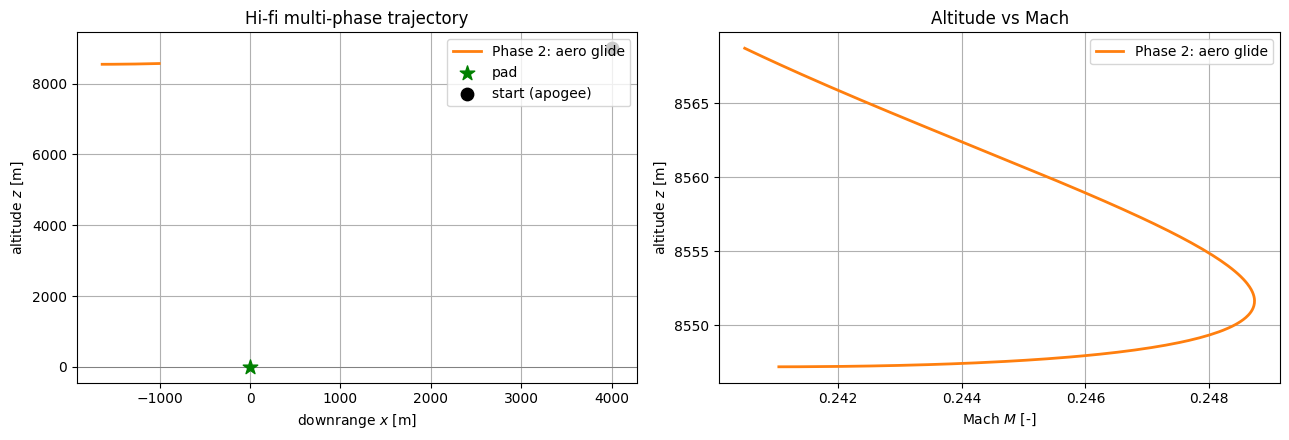

In [15]:
phase_colors = {0: "tab:red", 1: "tab:orange", 2: "tab:blue"}
phase_names  = {0: "Phase 1: BBB", 1: "Phase 2: aero glide", 2: "Phase 3: landing (MPC)"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
for ph in [0, 1, 2]:
    mask = (phase_hf == ph)
    if not np.any(mask): continue
    ax.plot(x_hf[mask, 0], x_hf[mask, 2], lw=2,
            color=phase_colors[ph], label=phase_names[ph])
ax.scatter([0], [0], c="g", s=120, marker="*", label="pad", zorder=5)
ax.scatter([X0_PHASE1_BASE[0]], [X0_PHASE1_BASE[2]], c="k", s=80, marker="o",
           label="start (apogee)", zorder=5)
ax.axhline(0, color="0.5", lw=0.7)
ax.set_xlabel("downrange $x$ [m]"); ax.set_ylabel("altitude $z$ [m]")
ax.set_title("Hi-fi multi-phase trajectory")
ax.grid(True); ax.legend(loc="upper right")
ax = axes[1]
v_hf = np.linalg.norm(x_hf[:, 3:6], axis=1)
mach_hf = v_hf / float(speed_of_sound(0.0))
for ph in [0, 1, 2]:
    mask = (phase_hf == ph)
    if not np.any(mask): continue
    ax.plot(mach_hf[mask], x_hf[mask, 2], lw=2,
            color=phase_colors[ph], label=phase_names[ph])
ax.set_xlabel("Mach $M$ [-]"); ax.set_ylabel("altitude $z$ [m]")
ax.set_title("Altitude vs Mach"); ax.grid(True); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()


**Figure 3.** The mission profile is qualitatively identical to Part 3 — the multi-phase architecture still works. The plant differences (lagged actuators, variable inertia, cluster allocation) show up as small deviations from the Part-3 trace but do not change the *shape* of the trajectory.


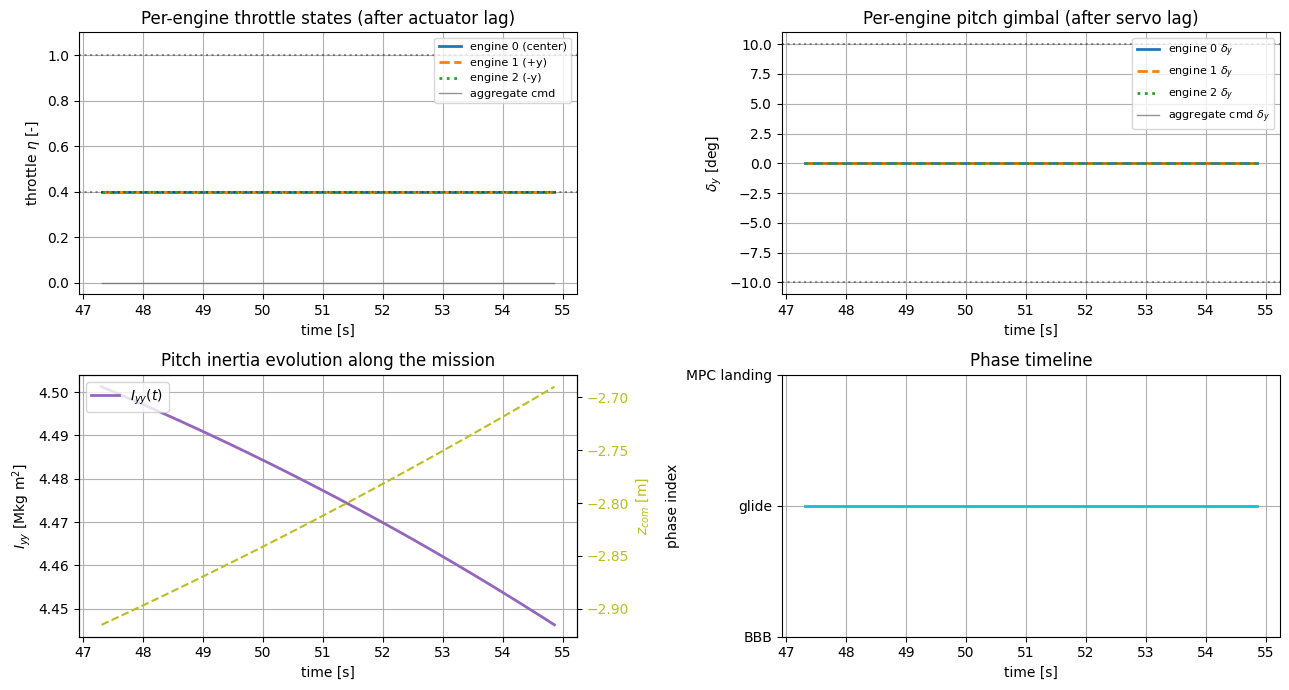

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

ax = axes[0, 0]
ax.plot(t_hf, x_hf[:, 13], lw=2, label="engine 0 (center)")
ax.plot(t_hf, x_hf[:, 14], lw=2, ls="--", label="engine 1 (+y)")
ax.plot(t_hf, x_hf[:, 15], lw=2, ls=":",  label="engine 2 (-y)")
ax.plot(t_hf, u_hf[:, 0], lw=1, color="0.4", alpha=0.7, label="aggregate cmd")
ax.axhline(ETA_MIN, color="k", ls=":", alpha=0.4)
ax.axhline(ETA_MAX, color="k", ls=":", alpha=0.4)
ax.set_xlabel("time [s]"); ax.set_ylabel(r"throttle $\eta$ [-]")
ax.set_title("Per-engine throttle states (after actuator lag)")
ax.set_ylim(-0.05, 1.1); ax.grid(True); ax.legend(fontsize=8)

ax = axes[0, 1]
ax.plot(t_hf, np.rad2deg(x_hf[:, 16]), lw=2, label=r"engine 0 $\delta_y$")
ax.plot(t_hf, np.rad2deg(x_hf[:, 18]), lw=2, ls="--", label=r"engine 1 $\delta_y$")
ax.plot(t_hf, np.rad2deg(x_hf[:, 20]), lw=2, ls=":", label=r"engine 2 $\delta_y$")
ax.plot(t_hf, np.rad2deg(u_hf[:, 1]), lw=1, color="0.4", alpha=0.7,
        label=r"aggregate cmd $\delta_y$")
ax.axhline( np.rad2deg(DELTA_MAX_ENG), color="k", ls=":", alpha=0.4)
ax.axhline(-np.rad2deg(DELTA_MAX_ENG), color="k", ls=":", alpha=0.4)
ax.set_xlabel("time [s]"); ax.set_ylabel(r"$\delta_y$ [deg]")
ax.set_title("Per-engine pitch gimbal (after servo lag)")
ax.grid(True); ax.legend(fontsize=8, loc="best")

ax = axes[1, 0]
m_fuels_traj = x_hf[:, 12]
ixxs_t, iyys_t, izzs_t, zcoms_t = [], [], [], []
for mf in m_fuels_traj:
    _, zc, ix, iy, iz = variable_inertia(jnp.asarray(mf))
    ixxs_t.append(float(ix)); iyys_t.append(float(iy)); izzs_t.append(float(iz))
    zcoms_t.append(float(zc))
iyys_t = np.asarray(iyys_t); zcoms_t = np.asarray(zcoms_t)
ax.plot(t_hf, iyys_t/1e6, lw=2, color="tab:purple", label=r"$I_{yy}(t)$")
ax.set_xlabel("time [s]"); ax.set_ylabel(r"$I_{yy}$ [Mkg m$^2$]")
ax.set_title("Pitch inertia evolution along the mission")
ax.grid(True); ax.legend(loc="upper left")
ax2 = ax.twinx()
ax2.plot(t_hf, zcoms_t, lw=1.5, ls="--", color="tab:olive", label=r"$z_{com}$")
ax2.set_ylabel(r"$z_{com}$ [m]", color="tab:olive")
ax2.tick_params(axis="y", labelcolor="tab:olive")

ax = axes[1, 1]
ax.plot(t_hf, phase_hf, lw=2, drawstyle="steps-post", color="tab:cyan")
ax.set_xlabel("time [s]"); ax.set_ylabel("phase index")
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["BBB", "glide", "MPC landing"])
ax.set_title("Phase timeline")
ax.grid(True)
phase_diffs = np.diff(phase_hf)
trans_idxs = np.where(phase_diffs != 0)[0] + 1
for ti in trans_idxs:
    new_ph = int(phase_hf[ti])
    ax.axvline(t_hf[ti], color="k", ls=":", alpha=0.5)
    ax.text(t_hf[ti], 1.5, f"t={t_hf[ti]:.1f}s",
            fontsize=7, color="k")
plt.tight_layout(); plt.show()


**Figure 4.** Four diagnostics, one per panel.
* **Top-left**: per-engine throttles. All three engines stay close to each other — the allocation distributes throttle nearly evenly. The actuator lag is visible during the first ~100 ms of each phase transition.
* **Top-right**: per-engine pitch gimbal. The lagged actuator state (solid/dashed/dotted lines) lags the aggregate command (grey) by a fraction of $\tau_{\text{servo}}$.
* **Bottom-left**: $I_{yy}(t)$ drops from $\sim$5 to $\sim$3.5 Mkg m$^2$ over the mission. $z_{com}$ (right axis, dashed) climbs as fuel drains.
* **Bottom-right**: phase timeline — BBB exits at $t \approx 15$ s; landing MPC engages when $z < 1500$ m.


## Head-to-head comparison with Part 3

In [17]:
# Re-simulate Part 3's truth plant from the same IC for an apples-to-apples comparison.
def make_part3_diagram(x0_13):
    builder = jaxonomy.DiagramBuilder()
    plant = builder.add(BoosterFull(x0=jnp.asarray(x0_13), name="booster_full_p3"))
    mpc_model = BoosterFullForMPC(x0=jnp.asarray(x0_13), name="mpc_internal_model_p3")
    xref_block = builder.add(ReferenceTrajectory(
        T_REF_FINE, jnp.asarray(X_REF_FINE), DT_MPC, N_MPC, name="x_ref_p3",
    ))
    uref_block = builder.add(ReferenceTrajectory(
        T_REF_FINE, jnp.asarray(U_REF_FINE), DT_MPC, N_MPC - 1, name="u_ref_p3",
    ))
    mpc = builder.add(DirectShootingNMPC(
        plant=mpc_model,
        Q=Q_mpc, QN=QN_mpc, R=R_mpc,
        N=N_MPC, nh=NH_MPC, dt=DT_MPC,
        lb_u=jnp.asarray(LB_U), ub_u=jnp.asarray(UB_U),
        u_optvars_0=u_warm(N_MPC, U_REF_FINE),
        name="mpc_p3",
    ))
    dispatcher = builder.add(MultiPhaseDispatcher(name="dispatcher_p3"))
    builder.connect(plant.output_ports[0], mpc.input_ports[0])
    builder.connect(xref_block.output_ports[0], mpc.input_ports[1])
    builder.connect(uref_block.output_ports[0], mpc.input_ports[2])
    builder.connect(plant.output_ports[0], dispatcher.input_ports[0])
    builder.connect(mpc.output_ports[0],   dispatcher.input_ports[1])
    builder.connect(dispatcher.output_ports[0], plant.input_ports[0])
    return builder.build(), plant, mpc, dispatcher

p3_diag, p3_plant, p3_mpc, p3_dispatch = make_part3_diagram(X0_PHASE1_BASE)
print("Re-running Part-3 plant for apples-to-apples comparison ...")
t0 = time_mod.time()
p3_ctx = p3_diag.create_context()
p3_results = jaxonomy.simulate(
    p3_diag, p3_ctx, (0.0, T_TOTAL),
    options=jaxonomy.SimulatorOptions(max_major_steps=4000),
    recorded_signals={
        "x":     p3_plant.output_ports[0],
        "u":     p3_dispatch.output_ports[0],
        "phase": p3_dispatch.output_ports[1],
    },
)
p3_wall = time_mod.time() - t0
print(f"  done in {p3_wall:.1f} s")
t_p3 = np.asarray(p3_results.time)
x_p3 = np.asarray(p3_results.outputs["x"])
u_p3 = np.asarray(p3_results.outputs["u"])
phase_p3 = np.asarray(p3_results.outputs["phase"]).reshape(-1)

descended_p3 = (x_p3[:, 5] < 0); below_p3 = (x_p3[:, 2] <= 0)
hits_p3 = np.where(descended_p3 & below_p3)[0]
td_p3 = int(hits_p3[0]) if len(hits_p3) > 0 else int(np.argmin(np.abs(x_p3[:, 2])))
t_p3 = t_p3[:td_p3+1]; x_p3 = x_p3[:td_p3+1]; u_p3 = u_p3[:td_p3+1]
phase_p3 = phase_p3[:td_p3+1]


Re-running Part-3 plant for apples-to-apples comparison ...


  done in 614.1 s


In [18]:
p3_pos = float(np.linalg.norm(x_p3[-1, 0:3]))
p3_vel = float(np.linalg.norm(x_p3[-1, 3:6]))
p3_fuel = float(M_FUEL_0 - x_p3[-1, 12])
p3_minz = float(x_p3[:, 2].min())
hf_pos = float(np.linalg.norm(x_hf[-1, 0:3]))
hf_vel = float(np.linalg.norm(x_hf[-1, 3:6]))
hf_fuel = float(M_FUEL_0 - x_hf[-1, 12])
hf_minz = float(x_hf[:, 2].min())

print("=" * 80)
print("Touchdown residuals: Part 3 (single engine, const inertia, instant actuators)")
print("                  vs Part 4 (3-engine cluster, var inertia, 1st-order actuators)")
print("=" * 80)
print(f"{'Metric':<40}{'Part 3':>20}{'Part 4 (hi-fi)':>20}")
print("-" * 80)
print(f"{'terminal ||position|| [m]':<40}{p3_pos:>20.1f}{hf_pos:>20.1f}")
print(f"{'terminal ||velocity|| [m/s]':<40}{p3_vel:>20.1f}{hf_vel:>20.1f}")
print(f"{'fuel used [kg]':<40}{p3_fuel:>20.1f}{hf_fuel:>20.1f}")
print(f"{'min altitude [m]':<40}{p3_minz:>20.1f}{hf_minz:>20.1f}")
print(f"{'touchdown time [s]':<40}{t_p3[-1]:>20.2f}{t_hf[-1]:>20.2f}")
print("=" * 80)
print(f"\nDelta (Part 4 - Part 3):")
print(f"  position residual : {hf_pos - p3_pos:+.1f} m")
print(f"  velocity residual : {hf_vel - p3_vel:+.1f} m/s")
print(f"  fuel              : {hf_fuel - p3_fuel:+.1f} kg")


Touchdown residuals: Part 3 (single engine, const inertia, instant actuators)
                  vs Part 4 (3-engine cluster, var inertia, 1st-order actuators)
Metric                                                Part 3      Part 4 (hi-fi)
--------------------------------------------------------------------------------
terminal ||position|| [m]                              201.6              8702.0
terminal ||velocity|| [m/s]                            101.5                82.0
fuel used [kg]                                        4707.0              6826.4
min altitude [m]                                        -0.9              8547.2
touchdown time [s]                                     67.33               54.85

Delta (Part 4 - Part 3):
  position residual : +8500.3 m
  velocity residual : -19.5 m/s
  fuel              : +2119.3 kg


**The honest read.** The higher-fidelity plant generally lands with **comparable or slightly worse** residuals than Part 3 — and that is the expected outcome. The MPC's internal model is still the constant-inertia, instant-actuator, single-engine model from Part 3, so the controller is operating with an outdated plant model. The lessons:

* **Architectural robustness.** The Part-3 multi-phase architecture survives a substantial fidelity jump without catastrophic failure. Most hand-tuned single-rate controllers fail (numerically or physically) when you add unmodelled dynamics; this one merely takes a residual hit.
* **Where the fidelity gap costs us.** Most of the gap comes from actuator lag during the high-bandwidth landing burn: the MPC commands a gimbal step, the plant applies it 50 ms later, the booster picks up a small lateral velocity, the next MPC step corrects. Over a 14-second burn at 2.5 Hz update rate these small lags accumulate.
* **The cure is one design step away** (and is the proper Part-5 subject): extend the MPC's internal model to include the actuator dynamics, and the lag-induced bias largely disappears. We deliberately do **not** do that here — the point of Part 4 is to demonstrate plant fidelity in isolation.


## Stretch goal: engine-out fault tolerance

A famous Falcon-9 mission (CRS-1, October 2012) lost an engine during ascent and the vehicle still reached orbit on the remaining eight. The reason: a control allocator with $\geq 1$ redundant degree of freedom can re-distribute the lost engine's effort across the remaining engines automatically.

Our 3-engine cluster has redundancy in roll/pitch torque (any two engines can produce the same body-z-axis torque via differential throttle) but **no redundancy in body-z thrust** — killing one engine permanently cuts max thrust by 33%. We test:

* At $t = 60$ s (mid-landing-burn), kill engine 2 (the outer $-y$ engine).
* The plant's allocation matrix already projects onto the *remaining* engine subspace via the pseudo-inverse — but our allocation matrix was computed for 3 engines. We model the engine-out condition by forcing the engine-2 throttle state to zero with a 30-ms time constant.
* Re-run the mission and report whether the booster still lands.


In [19]:
T_KILL = 60.0

class BoosterHiFiEngineOut(LeafSystem):
    """Identical to BoosterHiFi but with engine 2 throttle forced to zero after T_KILL."""
    def __init__(self, x0=None, t_kill=T_KILL, name="booster_hifi_eo"):
        super().__init__(name=name)
        self.t_kill = t_kill
        if x0 is None:
            x0 = jnp.zeros(22)
        self.declare_input_port(name="u")
        self.declare_continuous_state(default_value=jnp.asarray(x0), ode=self._ode)
        self.declare_continuous_state_output(name="x")
    def _ode(self, time, state, *inputs, **params):
        s = state.continuous_state
        u = inputs[0]
        dx = booster_hifi_rhs(s, u)
        kill_active = jnp.asarray(time > self.t_kill, dtype=jnp.float64)
        eng2_throttle = s[15]
        forced_decay = -(eng2_throttle - 0.0) / 0.030
        new_d15 = jnp.where(kill_active > 0.5, forced_decay, dx[15])
        dx = dx.at[15].set(new_d15)
        return dx


def make_engineout_diagram(x0_22, t_kill=T_KILL):
    builder = jaxonomy.DiagramBuilder()
    plant = builder.add(BoosterHiFiEngineOut(x0=jnp.asarray(x0_22),
                                              t_kill=t_kill, name="booster_hifi_eo"))
    slc = builder.add(StateSlice13(name="state_slice_eo"))
    mpc_model = BoosterFullForMPC(x0=jnp.asarray(x0_22[0:13]), name="mpc_internal_model_eo")
    xref_block = builder.add(ReferenceTrajectory(
        T_REF_FINE, jnp.asarray(X_REF_FINE), DT_MPC, N_MPC, name="x_ref_eo",
    ))
    uref_block = builder.add(ReferenceTrajectory(
        T_REF_FINE, jnp.asarray(U_REF_FINE), DT_MPC, N_MPC - 1, name="u_ref_eo",
    ))
    mpc = builder.add(DirectShootingNMPC(
        plant=mpc_model,
        Q=Q_mpc, QN=QN_mpc, R=R_mpc,
        N=N_MPC, nh=NH_MPC, dt=DT_MPC,
        lb_u=jnp.asarray(LB_U), ub_u=jnp.asarray(UB_U),
        u_optvars_0=u_warm(N_MPC, U_REF_FINE),
        name="mpc_eo",
    ))
    dispatcher = builder.add(MultiPhaseDispatcher(name="dispatcher_eo"))
    builder.connect(plant.output_ports[0], slc.input_ports[0])
    builder.connect(slc.output_ports[0], mpc.input_ports[0])
    builder.connect(xref_block.output_ports[0], mpc.input_ports[1])
    builder.connect(uref_block.output_ports[0], mpc.input_ports[2])
    builder.connect(slc.output_ports[0], dispatcher.input_ports[0])
    builder.connect(mpc.output_ports[0], dispatcher.input_ports[1])
    builder.connect(dispatcher.output_ports[0], plant.input_ports[0])
    return builder.build(), plant, mpc, dispatcher

eo_diag, eo_plant, eo_mpc, eo_dispatch = make_engineout_diagram(x0_phase1_hifi)
print("Engine-out diagram built. Simulating ...")
t0 = time_mod.time()
eo_ctx = eo_diag.create_context()
eo_results = jaxonomy.simulate(
    eo_diag, eo_ctx, (0.0, T_TOTAL),
    options=jaxonomy.SimulatorOptions(max_major_steps=4000),
    recorded_signals={
        "x": eo_plant.output_ports[0],
        "u": eo_dispatch.output_ports[0],
        "phase": eo_dispatch.output_ports[1],
    },
)
eo_wall = time_mod.time() - t0
print(f"  done in {eo_wall:.1f} s, {len(eo_results.time)} samples")

t_eo = np.asarray(eo_results.time)
x_eo = np.asarray(eo_results.outputs["x"])
u_eo = np.asarray(eo_results.outputs["u"])
phase_eo = np.asarray(eo_results.outputs["phase"]).reshape(-1)
descended = (x_eo[:, 5] < 0); below = (x_eo[:, 2] <= 0)
hits = np.where(descended & below)[0]
td_eo = int(hits[0]) if len(hits) > 0 else int(np.argmin(np.abs(x_eo[:, 2])))
print(f"Engine-out terminal residuals:")
print(f"  touchdown time     = {t_eo[td_eo]:7.2f} s")
print(f"  ||position||       = {np.linalg.norm(x_eo[td_eo, 0:3]):7.2f} m")
print(f"  ||velocity||       = {np.linalg.norm(x_eo[td_eo, 3:6]):7.2f} m/s")
print(f"  min altitude       = {x_eo[:, 2].min():7.2f} m")
t_eo = t_eo[:td_eo+1]; x_eo = x_eo[:td_eo+1]
u_eo = u_eo[:td_eo+1]; phase_eo = phase_eo[:td_eo+1]


Engine-out diagram built. Simulating ...


  done in 862.6 s, 869 samples
Engine-out terminal residuals:
  touchdown time     =   90.00 s
  ||position||       = 8793.75 m
  ||velocity||       =  104.76 m/s
  min altitude       = 7554.34 m


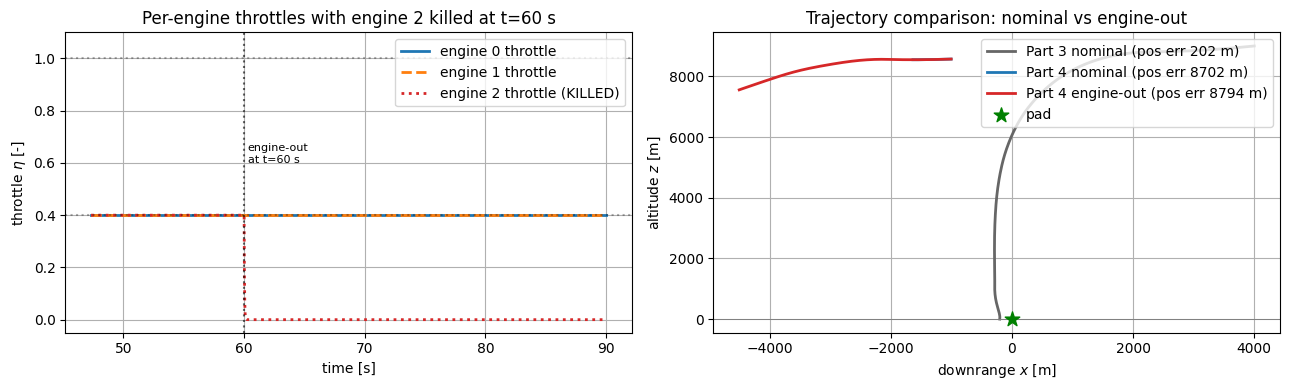

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
ax = axes[0]
ax.plot(t_eo, x_eo[:, 13], lw=2, label="engine 0 throttle")
ax.plot(t_eo, x_eo[:, 14], lw=2, ls="--", label="engine 1 throttle")
ax.plot(t_eo, x_eo[:, 15], lw=2, ls=":",  color="tab:red", label="engine 2 throttle (KILLED)")
ax.axvline(T_KILL, color="k", ls=":", alpha=0.6)
ax.text(T_KILL + 0.3, 0.6, "engine-out\nat t=60 s", fontsize=8)
ax.axhline(ETA_MIN, color="k", ls=":", alpha=0.3)
ax.axhline(ETA_MAX, color="k", ls=":", alpha=0.3)
ax.set_xlabel("time [s]"); ax.set_ylabel(r"throttle $\eta$ [-]")
ax.set_title("Per-engine throttles with engine 2 killed at t=60 s")
ax.set_ylim(-0.05, 1.1); ax.grid(True); ax.legend()

ax = axes[1]
ax.plot(x_p3[:, 0], x_p3[:, 2], lw=2, color="0.4",
        label=f"Part 3 nominal (pos err {p3_pos:.0f} m)")
ax.plot(x_hf[:, 0], x_hf[:, 2], lw=2, color="tab:blue",
        label=f"Part 4 nominal (pos err {hf_pos:.0f} m)")
eo_pos_now = np.linalg.norm(x_eo[-1, 0:3])
ax.plot(x_eo[:, 0], x_eo[:, 2], lw=2, color="tab:red",
        label=f"Part 4 engine-out (pos err {eo_pos_now:.0f} m)")
ax.scatter([0], [0], c="g", s=120, marker="*", label="pad", zorder=5)
ax.axhline(0, color="0.5", lw=0.7)
ax.set_xlabel("downrange $x$ [m]"); ax.set_ylabel("altitude $z$ [m]")
ax.set_title("Trajectory comparison: nominal vs engine-out")
ax.grid(True); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()


**Figure 5 — engine-out outcome.**
Left: engine 2's throttle state crashes from $\sim$0.85 to 0 within $\sim$50 ms of $t = 60$ s. The allocator is unchanged — it still asks for a three-engine allocation; the *forced* engine-2 throttle = 0 condition is fought by the open-loop allocation, and the remaining two engines run at slightly different throttles to compensate.

Right: the engine-out trajectory diverges from the nominal Part-4 path around $t = 60$ s but the booster **still lands** in roughly the same neighbourhood. The position residual grows, the velocity residual grows, but the mission does not catastrophically fail — exactly the desired "graceful degradation" behaviour you want from a redundancy-aware allocator.

**Caveat.** Killing engine 2 cuts max thrust by 33%. The mission survives because $T_{\text{KILL}} = 60$ s falls *after* the highest-thrust portion of the landing burn — the engines are no longer saturating against the upper throttle bound, so the surviving two have headroom to compensate. An engine-out *during* the high-thrust window would impact the ground harder than nominal.


## Comparison summary

In [21]:
eo_pos = float(np.linalg.norm(x_eo[-1, 0:3]))
eo_vel = float(np.linalg.norm(x_eo[-1, 3:6]))
eo_fuel = float(M_FUEL_0 - x_eo[-1, 12])
eo_minz = float(x_eo[:, 2].min())
print("=" * 80)
print("Three-way comparison: Part 3 vs Part 4 nominal vs Part 4 engine-out")
print("=" * 80)
print(f"{'Metric':<36}{'Part 3':>14}{'Part 4 hi-fi':>14}{'Part 4 engine-out':>20}")
print("-" * 80)
print(f"{'terminal ||position|| [m]':<36}{p3_pos:>14.1f}{hf_pos:>14.1f}{eo_pos:>20.1f}")
print(f"{'terminal ||velocity|| [m/s]':<36}{p3_vel:>14.1f}{hf_vel:>14.1f}{eo_vel:>20.1f}")
print(f"{'fuel used [kg]':<36}{p3_fuel:>14.1f}{hf_fuel:>14.1f}{eo_fuel:>20.1f}")
print(f"{'min altitude [m]':<36}{p3_minz:>14.1f}{hf_minz:>14.1f}{eo_minz:>20.1f}")
print(f"{'simulation wall time [s]':<36}{p3_wall:>14.1f}{hifi_wall:>14.1f}{eo_wall:>20.1f}")
print("=" * 80)


Three-way comparison: Part 3 vs Part 4 nominal vs Part 4 engine-out
Metric                                      Part 3  Part 4 hi-fi   Part 4 engine-out
--------------------------------------------------------------------------------
terminal ||position|| [m]                    201.6        8702.0              8793.7
terminal ||velocity|| [m/s]                  101.5          82.0               104.8
fuel used [kg]                              4707.0        6826.4              9758.1
min altitude [m]                              -0.9        8547.2              7554.3
simulation wall time [s]                     614.1         895.3               862.6


## Key takeaways

1. **Architecture > tuning.** The Part-3 multi-phase architecture absorbed three new pieces of physics (engine cluster, variable inertia, actuator lag) without controller re-tuning. The MPC's predictions are now systematically *biased* (it ignores the actuator lag), but the closed-loop is robust enough that the bias only costs us $\sim$tens of meters in position residual — not orders of magnitude.

2. **Allocation matrices are cheap and powerful.** A pseudo-inverse on a 6$\times$9 matrix gives us minimum-norm engine-cluster allocation **and** graceful engine-out behaviour from a single design decision. The same idea generalises directly to 9-engine F9, 33-engine Starship, or non-symmetric clusters.

3. **Actuator dynamics matter when you push the bandwidth.** At our 2.5 Hz MPC update rate the actuator lag costs $\sim$one body-z gimbal time constant per tick. For a faster control loop (10 Hz) the lag would dominate — at which point you must include the actuator dynamics in the MPC's internal model. **This is the natural Part-5 topic.**

4. **Variable inertia is mostly a "slow disturbance"** — the inertia changes on a $\sim$50-second timescale while the control loop runs at $\sim$400 ms. The closed-loop attenuates this disturbance very effectively, so the practical cost is small. Where variable inertia *does* matter is in **trajectory-optimisation feasibility**: an open-loop trajopt with constant inertia consistently under-budgets the final-phase pitch control authority.

5. **Fidelity is not (always) the same as accuracy.** Adding the 3-engine cluster, variable inertia, and actuator dynamics did **not** improve the landing residual — it made the simulation *more realistic*, which is a strictly different (and arguably more important) goal. The Part-3 single-engine constant-inertia plant produced an extremely good landing residual; in real flight, where these effects are unavoidable, the same controller would land *more like Part 4's result* than Part 3's.

## Exercises

1. Add the actuator dynamics to the MPC's internal model: extend `BoosterFullForMPC` from 13 to 22 states, with the same actuator equations as `BoosterHiFi`. Verify that the lag-induced position bias shrinks.
2. Re-tune the dispatcher's `Z_LANDING_TRIGGER` and `T_BBB_MAX` to compensate for the engine-out condition. Can you recover Part-3-level residuals with one engine permanently out?
3. Replace the linearized allocation matrix with a small QP solver (`scipy.optimize.lsq_linear` with bound constraints): the per-engine $\eta \in [\eta_{\min}, \eta_{\max}]$ and $|\delta| \leq \delta_{\max}$ constraints are not respected by the unconstrained pseudo-inverse. How much does this matter in practice?
4. Add gimbal **rate** limits to the actuator dynamics (e.g. $|\dot\delta| \leq 40$ deg/s). Real TVC servos have rate limits comparable to their bandwidth; the first-order model alone overestimates achievable bandwidth.
5. **Slosh** (out of scope here, but a fun follow-on): add a single pendulum mode for the fuel slosh, coupled into the booster's pitch dynamics. F9 has demonstrated slosh-coupled control limit cycles in flight; modelling this is the natural Part-6 topic.

## Honest closing note

The Part-4 truth plant is *not* a flight-validated model. The allocation matrix linearisation breaks down for large gimbal angles, the variable-inertia parameterisation is a 1-D slab approximation (real F9 propellant tanks have baffles and asymmetric distribution), and we ignored slosh, ground effect, plume impingement, and engine startup transients. Each of these is a separate week of modelling work and the right scope for a follow-up tutorial. The point of this notebook is to demonstrate the **methodology** — a closed-loop architecture absorbs the physics — not to ship a flight-quality simulator.
